<a href="https://colab.research.google.com/github/Dev5710/data555/blob/main/DATA555_Project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
"""Fetch, clean, and prepare the dataset"""

import pandas as pd
!pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

breast_cancer_data = fetch_ucirepo(id=17)  # from: https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic
breast_cancer_features = pd.DataFrame(breast_cancer_data.data.features)
for column in breast_cancer_features.columns:
  if breast_cancer_features[column].dtypes == 'object':
    breast_cancer_features[column] = breast_cancer_features[column].str.strip()  # remove whitespace from feature data
    breast_cancer_features[column] = breast_cancer_features[column].astype(float)  # convert feature data to float
breast_cancer_diagnoses = pd.DataFrame(breast_cancer_data.data.targets)  # extract diagnosis data
breast_cancer_diagnoses['Diagnosis'] = breast_cancer_diagnoses['Diagnosis'].str.strip()  # remove whitespace from diagnosis data
breast_cancer_data = breast_cancer_features.join(breast_cancer_diagnoses) # code based on pandas documentation: https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.join.html#pandas.DataFrame.join
breast_cancer_data_clean = breast_cancer_data.drop_duplicates()  # remove duplicates
print('')
print(f"Duplicate entries found and removed: {len(breast_cancer_data)-len(breast_cancer_data_clean)}")
print('')
print('Missing valuyes per column before cleaning:')
print(breast_cancer_data_clean.isnull().mean())
print('')
breast_cancer_data = breast_cancer_data_clean.dropna()  # drop missing values
print('Missing values per column after cleaning:')
print(breast_cancer_data.isnull().mean())
print('')
breast_cancer_data.to_csv("breast_cancer_data_cleaned.csv")


Duplicate values removed: 0

Missing valuyes per column before cleaning:
radius1               0.0
texture1              0.0
perimeter1            0.0
area1                 0.0
smoothness1           0.0
compactness1          0.0
concavity1            0.0
concave_points1       0.0
symmetry1             0.0
fractal_dimension1    0.0
radius2               0.0
texture2              0.0
perimeter2            0.0
area2                 0.0
smoothness2           0.0
compactness2          0.0
concavity2            0.0
concave_points2       0.0
symmetry2             0.0
fractal_dimension2    0.0
radius3               0.0
texture3              0.0
perimeter3            0.0
area3                 0.0
smoothness3           0.0
compactness3          0.0
concavity3            0.0
concave_points3       0.0
symmetry3             0.0
fractal_dimension3    0.0
Diagnosis             0.0
dtype: float64

Missing values per column after cleaning:
radius1               0.0
texture1              0.0
perimeter1

The dataset appears to be of good quality, with no duplicate entries or missing values present.

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

M vs. B: t-test independent samples, P_val:8.466e-96 t=2.544e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

M vs. B: t-test independent samples, P_val:4.059e-25 t=1.087e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

M vs. B: t-test independent samples, P_val:8.436e-101 t=2.641e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

M vs. B: t-test independent samples,

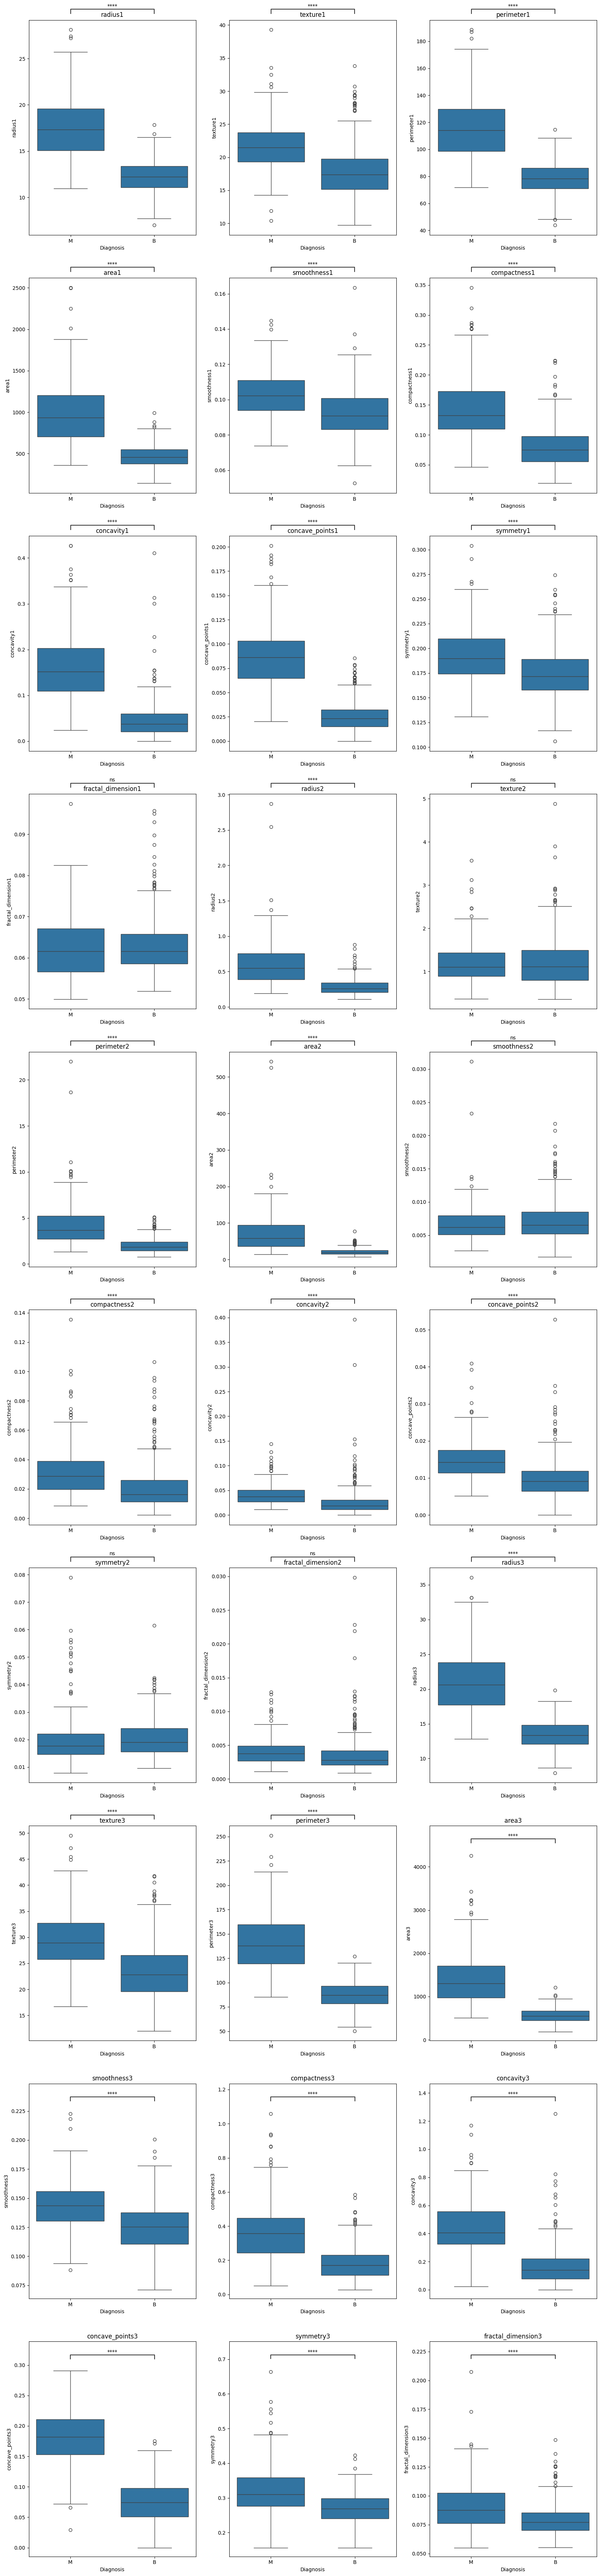

In [ ]:
"""Perform an exploratory analysis by plotting the data"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

!pip install statannotations
import statannotations
from statannotations.Annotator import Annotator

breast_cancer_data=pd.read_csv("breast_cancer_data_cleaned.csv")  # import data
pairs = [("M", "B")]  # define groups of interest
fig, axes = plt.subplots(10, 3, figsize=(20, 90))  # define parameters of plot

# the following steps were completed for all 30 features in the dataset; the code is only annotated the first time
sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="radius1", ax=axes[0,0])  # define boxplot, adapted from: https://levelup.gitconnected.com/statistics-on-seaborn-plots-with-statannotations-2bfce0394c00
axes[0,0].set_title("radius1")  # set boxplot title, adapted from: https://levelup.gitconnected.com/statistics-on-seaborn-plots-with-statannotations-2bfce0394c00
sig_bars_annot = Annotator(axes[0,0], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="radius1")  # define annotator to add significance bars to plot, adapted from: https://levelup.gitconnected.com/statistics-on-seaborn-plots-with-statannotations-2bfce0394c00
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")  # define t-test to be used for significance bar creation, adapted from: https://levelup.gitconnected.com/statistics-on-seaborn-plots-with-statannotations-2bfce0394c00
sig_bars_annot.apply_and_annotate()  # perform t-testing and annotate plot with significance bar

sns.boxplot(data=breast_cancer_data, x=breast_cancer_data["Diagnosis"], y=breast_cancer_data["texture1"], ax=axes[0,1])
axes[0,1].set_title("texture1")
sig_bars_annot = Annotator(axes[0,1], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="texture1")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="perimeter1", ax=axes[0,2])
axes[0,2].set_title("perimeter1")
sig_bars_annot = Annotator(axes[0,2], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="perimeter1")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="area1", ax=axes[1,0])
axes[1,0].set_title("area1")
sig_bars_annot = Annotator(axes[1,0], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="area1")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="smoothness1", ax=axes[1,1])
axes[1,1].set_title("smoothness1")
sig_bars_annot = Annotator(axes[1,1], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="smoothness1")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="compactness1", ax=axes[1,2])
axes[1,2].set_title("compactness1")
sig_bars_annot = Annotator(axes[1,2], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="compactness1")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="concavity1", ax=axes[2,0])
axes[2,0].set_title("concavity1")
sig_bars_annot = Annotator(axes[2,0], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="concavity1")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="concave_points1", ax=axes[2,1])
axes[2,1].set_title("concave_points1")
sig_bars_annot = Annotator(axes[2,1], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="concave_points1")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="symmetry1", ax=axes[2,2])
axes[2,2].set_title("symmetry1")
sig_bars_annot = Annotator(axes[2,2], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="symmetry1")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="fractal_dimension1", ax=axes[3,0])
axes[3,0].set_title("fractal_dimension1")
sig_bars_annot = Annotator(axes[3,0], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="fractal_dimension1")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="radius2", ax=axes[3,1])
axes[3,1].set_title("radius2")
sig_bars_annot = Annotator(axes[3,1], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="radius2")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="texture2", ax=axes[3,2])
axes[3,2].set_title("texture2")
sig_bars_annot = Annotator(axes[3,2], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="texture2")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="perimeter2", ax=axes[4,0])
axes[4,0].set_title("perimeter2")
sig_bars_annot = Annotator(axes[4,0], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="perimeter2")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="area2", ax=axes[4,1])
axes[4,1].set_title("area2")
sig_bars_annot = Annotator(axes[4,1], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="area2")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="smoothness2", ax=axes[4,2])
axes[4,2].set_title("smoothness2")
sig_bars_annot = Annotator(axes[4,2], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="smoothness2")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="compactness2", ax=axes[5,0])
axes[5,0].set_title("compactness2")
sig_bars_annot = Annotator(axes[5,0], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="compactness2")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="concavity2", ax=axes[5,1])
axes[5,1].set_title("concavity2")
sig_bars_annot = Annotator(axes[5,1], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="concavity2")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="concave_points2", ax=axes[5,2])
axes[5,2].set_title("concave_points2")
sig_bars_annot = Annotator(axes[5,2], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="concave_points2")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="symmetry2", ax=axes[6,0])
axes[6,0].set_title("symmetry2")
sig_bars_annot = Annotator(axes[6,0], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="symmetry2")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="fractal_dimension2", ax=axes[6,1])
axes[6,1].set_title("fractal_dimension2")
sig_bars_annot = Annotator(axes[6,1], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="fractal_dimension2")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="radius3", ax=axes[6,2])
axes[6,2].set_title("radius3")
sig_bars_annot = Annotator(axes[6,2], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="radius3")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="texture3", ax=axes[7,0])
axes[7,0].set_title("texture3")
sig_bars_annot = Annotator(axes[7,0], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="texture3")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="perimeter3", ax=axes[7,1])
axes[7,1].set_title("perimeter3")
sig_bars_annot = Annotator(axes[7,1], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="perimeter3")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="outside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="area3", ax=axes[7,2])
axes[7,2].set_title("area3")
sig_bars_annot = Annotator(axes[7,2], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="area3")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="inside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="smoothness3", ax=axes[8,0])
axes[8,0].set_title("smoothness3")
sig_bars_annot = Annotator(axes[8,0], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="smoothness3")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="inside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="compactness3", ax=axes[8,1])
axes[8,1].set_title("compactness3")
sig_bars_annot = Annotator(axes[8,1], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="compactness3")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="inside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="concavity3", ax=axes[8,2])
axes[8,2].set_title("concavity3")
sig_bars_annot = Annotator(axes[8,2], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="concavity3")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="inside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="concave_points3", ax=axes[9,0])
axes[9,0].set_title("concave_points3")
sig_bars_annot = Annotator(axes[9,0], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="concave_points3")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="inside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="symmetry3", ax=axes[9,1])
axes[9,1].set_title("symmetry3")
sig_bars_annot = Annotator(axes[9,1], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="symmetry3")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="inside")
sig_bars_annot.apply_and_annotate()

sns.boxplot(data=breast_cancer_data, x="Diagnosis", y="fractal_dimension3", ax=axes[9,2])
axes[9,2].set_title("fractal_dimension3")
sig_bars_annot = Annotator(axes[9,2], [("M", "B")], data=breast_cancer_data, x="Diagnosis", y="fractal_dimension3")
sig_bars_annot.configure(test="t-test_ind", text_format="star", loc="inside")
sig_bars_annot.apply_and_annotate()

plt.show()  # display boxplots


As we are interested in predicting a categorical variable (Diagnosis) based on 30 numerical variables, I wanted to see if/how many of these 30 variables differed between patients with each Diagnosis (Benign vs Malignant). I thus elected to create boxplots for each of the 30 features of interest comparing their distributions between the two groups. I also performed t-testing for each of the 30 features, which showed that 25 were significantly different (p<0.05) between diagnoses, suggesting that a classifier model trained on these features may be able to distinguish Benign from Malignant cases.  

Original Model Accuracy: 0.9649122807017544

Original Model Precision: 0.975609756097561

Original Model Recall: 0.9302325581395349

Original Model F1: 0.9523809523809523



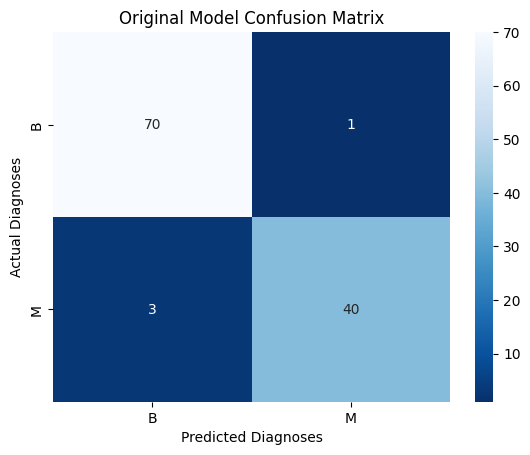



Features selected: ['radius1' 'texture1' 'perimeter1' 'area1' 'concavity1' 'concave_points1'
 'area2' 'radius3' 'texture3' 'perimeter3' 'area3' 'smoothness3'
 'concavity3' 'concave_points3' 'symmetry3']

Grid search best parameters: {'max_features': 'log2', 'n_estimators': 1000}

Tuned Model Accuracy: 0.9649122807017544

Tuned Model Precision: 0.975609756097561

Tuned Model Recall: 0.9302325581395349

Tuned Model F1: 0.9523809523809523



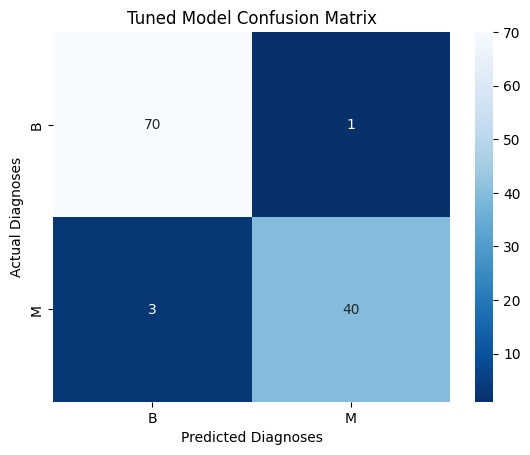

In [ ]:
"""Create and test the original and tuned models"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
import seaborn as sns
from sklearn.metrics import confusion_matrix

breast_cancer_data=pd.read_csv("breast_cancer_data_cleaned.csv")

# split data into training (80%) and testing (20%) sets
breast_cancer_features = breast_cancer_data.columns.drop(['Diagnosis'])
X = breast_cancer_data[breast_cancer_features]  # define features for classifier model
y = breast_cancer_data['Diagnosis']  # define target for classifier model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # split data into training (80%) and testing (20%) sets, adapted from course content and: https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/

# train and test initial model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)  # split data into training (80%) and testing (20%) sets, adapted from course content and:
classifier = RandomForestClassifier(n_estimators=100, random_state=42, oob_score=True)  # define Random Forest Classifier, adapted from course content and: https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/
classifier.fit(X_train, y_train)  # train classifier model, adapted from course content and: https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/
y_pred = classifier.predict(X_test)  # test classifier on test data, adapted from course content and:  https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/
accuracy = sklearn.metrics.accuracy_score(y_test, y_pred)  # determine original model accuracy for test set
print("Original Model Accuracy:", accuracy)
print('')
precision = sklearn.metrics.precision_score(y_test, y_pred, pos_label='M')  # determine original model precision for test set
print("Original Model Precision:", precision)
print('')
recall = sklearn.metrics.recall_score(y_test, y_pred, pos_label='M')  # determine original model recall for test set
print("Original Model Recall:", recall)
print('')
f1 = sklearn.metrics.f1_score(y_test, y_pred, pos_label='M')  # determine original model f1 for test set
print("Original Model F1:", f1)
print('')
conf_m = confusion_matrix(y_test, y_pred)  # obtain confusion matrix for original model
conf_m_plt=sns.heatmap(conf_m, annot=True, cmap='Blues_r', xticklabels=['B', 'M'], yticklabels=['B', 'M'])  # plot confusion matrix, code adapted from course content based on: https://seaborn.pydata.org/generated/seaborn.heatmap.html
conf_m_plt.set_xlabel('Predicted Diagnoses')  # set confusion matrix plot x-axis label, adapted from: https://seaborn.pydata.org/generated/seaborn.heatmap.html
conf_m_plt.set_ylabel('Actual Diagnoses')  # set confusion matrix plot y-axis label, adapted from: https://seaborn.pydata.org/generated/seaborn.heatmap.html
conf_m_plt.set_title('Original Model Confusion Matrix')
plt.show()
print('')

# perform feature selection
rfe = RFE(classifier)  # define feature selection method/function, adapted from: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html
rfe.fit(X_train,y_train)  # perform feature selection, adapted from: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html
selected_features = np.array(breast_cancer_features)[rfe.get_support()]  # extract most important features from feature selection results, adapted from: https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.RFE.html
print('')
print(f"Features selected: {selected_features}")
print('')
X_train2 = X_train[selected_features]  # define new training set with only the 15 selected features
X_test2 = X_test[selected_features]  # define new test set with only the 15 selected features

# perform grid search for hyperparameter tuning
parameter_grid = {'n_estimators':[10, 100, 1000], 'max_features':['sqrt', 'log2', len(selected_features)]}  # define parameters to search, adapted from course content and: https://towardsdatascience.com/a-visual-guide-to-tuning-random-forest-hyperparameters/
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=1001)  # adapted from course content and: https://towardsdatascience.com/a-visual-guide-to-tuning-random-forest-hyperparameters/
grid_search = GridSearchCV(estimator=RandomForestClassifier(), param_grid=parameter_grid, n_jobs=-1, cv=cv, scoring='accuracy')  # prepare grid search for hyperparameter tuning, adapted from course content and: https://towardsdatascience.com/a-visual-guide-to-tuning-random-forest-hyperparameters/
grid_result = grid_search.fit(X_train2, y_train)  # complete grid search on training set, adapted from course content and: https://towardsdatascience.com/a-visual-guide-to-tuning-random-forest-hyperparameters/
print(f"Grid search best parameters: {grid_result.best_params_}")
print('')
n_estimators_tuned = grid_result.best_params_["n_estimators"]
max_features_tuned = grid_result.best_params_["max_features"]

# train and test tuned model
classifier_tuned = RandomForestClassifier(n_estimators = n_estimators_tuned, max_features = max_features_tuned)  # define random forest classifier with new parameters, adapted from course content and: https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/
classifier_tuned.fit(X_train2, y_train)  # train tuned model, adapted from course content and: https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/
y_pred_tuned = classifier_tuned.predict(X_test2)  # apply tuned model to test set, adapted from course content and: https://www.geeksforgeeks.org/random-forest-classifier-using-scikit-learn/

# calculate performance metrics for tuned model
accuracy_tuned = sklearn.metrics.accuracy_score(y_test, y_pred_tuned)  # determine tuned model accuracy for test set
print("Tuned Model Accuracy:", accuracy_tuned)
print('')
precision_tuned = sklearn.metrics.precision_score(y_test, y_pred_tuned, pos_label='M')  # determine tuned model precision for test set
print("Tuned Model Precision:", precision_tuned)
print('')
recall_tuned = sklearn.metrics.recall_score(y_test, y_pred_tuned, pos_label='M')  # determine tuned model precision for test set
print("Tuned Model Recall:", recall_tuned)
print('')
f1_tuned = sklearn.metrics.f1_score(y_test, y_pred_tuned, pos_label='M')  # determine tuned model precision for test set
print("Tuned Model F1:", f1_tuned)
print('')
conf_m = confusion_matrix(y_test, y_pred)  # obtain confusion matrix for tuned model
conf_m_plt=sns.heatmap(conf_m, annot=True, cmap='Blues_r', xticklabels=['B', 'M'], yticklabels=['B', 'M'])  # plot confusion matrix, code adapted from course content and: https://seaborn.pydata.org/generated/seaborn.heatmap.html
conf_m_plt.set_xlabel('Predicted Diagnoses')  # set confusion matrix plot x-axis label, adapted from: https://seaborn.pydata.org/generated/seaborn.heatmap.html
conf_m_plt.set_ylabel('Actual Diagnoses')  # set confusion matrix plot y-axis label, adapted from: https://seaborn.pydata.org/generated/seaborn.heatmap.html
conf_m_plt.set_title('Tuned Model Confusion Matrix')
plt.show()
print('')

2.
When applied to the test dataset, the original (untuned) model demonstrated strong accuracy (0.9649) and precision (0.9756), meaning that 96.49% of predictions made were correct and 97.56% of cases predicted as Malignant were accurate. Notably, the recall was comparatively lower (0.9302), meaning that only 93.02% of Malignant cases were identified by the model and bringing the F1 score down to a still-strong 0.9523. This could potentially be improved by reducing the number of features considered by the model (thus reducing the risk of overfitting) and/or by performing hyperparameter tuning, where the input parameters employed by the model are adjusted to maximize model performance.

3.
Feature selection narrowed down the original 30 features in the dataset to the 15 most important for predicting Diagnoses. Notably, all 15 of these features showed significant differences between the Benign and Malignant cases in the boxplots created earlier. By reducing the number of features evaluated in the model, we may be able to reduce the risk of overfitting and decrease the computational power needed for the model ().

Next, grid search determined that the best max_features parameter was 'log2', while the ideal number of estimators (between 10, 100, and 1000) was 1000. Both of these differ from the original model, which used max_features=# and n_estimators=# (the default settings) ().

While it should be expected that this feature selection and hyperparameter tuning would improve the model's performance, all 4 performance metrics evaluated (Accuracy, Precision, Recall, and F1) were identical between the original and tuned models. As discussed in the course content, random forest models are quite stable which may explain these results. Additionally, the exceptional performance of the original model may have been difficult to improve upon. It is notable that the fine-tuned model with 15 features performed the same as the model with 30 features, demonstrating that it is possible to achieve similar performance with this smaller set of parameters, which could reduce the practical and financial costs of employing such a model in a wider real-world setting.